[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01/blob/main/defect_detection.ipynb)

TODO: fix the button

# PBF Defect Detection

This notebook covers data loading, training, validation, and inference for detecting defects in Powder Bed Fusion images using a fine-tuned CNN.

## Clone GithHub repo

In [ ]:
!rm -rf mla_project/

In [5]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN

  # change the name of the branch here as needed
  !git clone -b giorgia https://***REMOVED-GITHUB-TOKEN***@github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 809 bytes | 404.00 KiB/s, done.
From https://github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01
   732a53f..41d5297  giorgia    -> origin/giorgia
Updating 732a53f..41d5297
Fast-forward
 src/data_loader.py | 16 ++--------------
 src/train.py       | 52 ++++++++++++++++++++++++++--------------------------
 2 files changed, 28 insertions(+), 40 deletions(-)


## Install Dependencies

In [2]:
!pip install torch torchvision matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Dataset mean and std

In [ ]:
!python /content/mla_project/src/data_loader.py --data-dir /content/mla_project/images --compute-stats

Images shape:  torch.Size([16, 1, 1024, 1280])
Images shape:  torch.Size([16, 1, 1024, 1280])
Images shape:  torch.Size([16, 1, 1024, 1280])
Images shape:  torch.Size([16, 1, 1024, 1280])
Images shape:  torch.Size([10, 1, 1024, 1280])
Dataset mean (grayscale): 0.5830
Dataset std (grayscale): 0.2075


## Training - no augmentation

### Define paths and parameters

In [4]:
data_dir = '/content/mla_project/images'
train_dir = os.path.join(data_dir, 'train')
val_dir   = os.path.join(data_dir, 'val')

# Training params
batch_size = 1
epochs = 10
learning_rate = 1e-3
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Test Loading data

In [ ]:
# !python /content/mla_project/src/data_loader.py \
#     --data-dir "{data_dir}" \
#     --batch-size {batch_size} \
#     --val-split 0.2 \
#     --num-workers 2

Number of training batches: 59
Number of validation batches: 15


### Launch training

In [20]:
# Execute train script directly

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --k-folds 5

Training with K-Fold cross-validation
Using device: cuda
aug:  False

===== Fold 1 =====
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Fold 1] Epoch 1/10 | Train Loss: 0.6463, Acc: 0.6441 | Val Loss: 0.5574, Acc: 0.8667, Precision: 0.9000, Recall: 0.8667, F1: 0.8679
     Confusion Matrix - Fold 1  - Epoch 1 (Validation):
     [6 0]
     [2 7]


[Fold 1] Epoch 2/10 | Train Loss: 0.1632, Acc: 0.9661 | Val Loss: 0.1052, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
     Confusion Matrix - Fold 1  - Epoch 2 (Validation):
     [6 0]
     [0 9]


[Fold 1] Epoch 3/10 | Train Loss: 0.0065, Acc: 1.0000 | Val Loss: 0.3811, Acc: 0.6

### Plot Training & Validation Curves

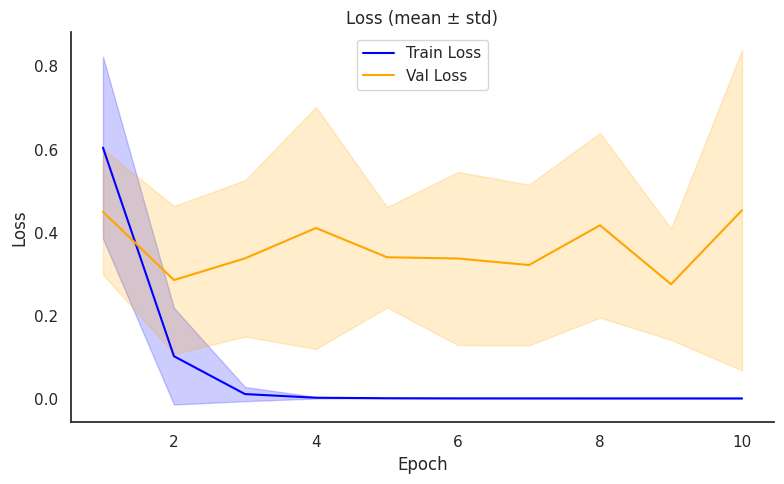

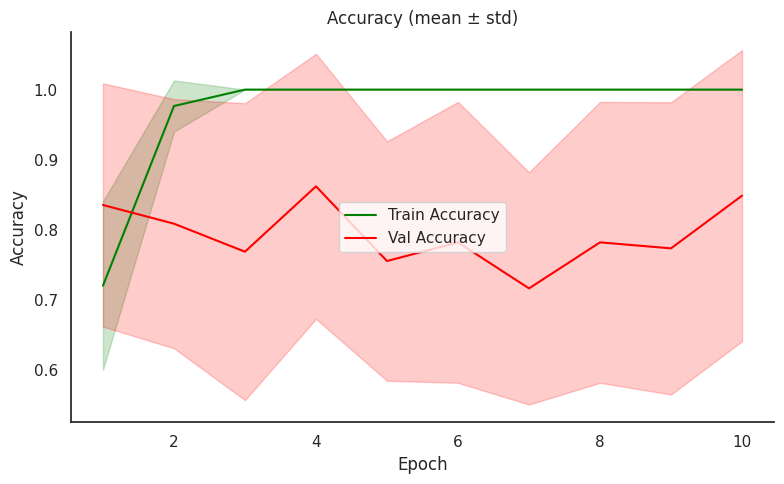

In [23]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


## Training - basic augmentations (simple transformations)

In [22]:
!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --k-folds 5 \
    --aug "True"

Training with K-Fold cross-validation
Using device: cuda
aug:  True

===== Fold 1 =====
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Traceback (most recent call last):
  File "/content/mla_project/src/train.py", line 286, in <module>
    train_kfold(args)
  File "/content/mla_project/src/train.py", line 256, in train_kfold
    logs = train_one_fold(train_idx, val_idx, file_paths, labels, device, args, fold, class_weights, aug)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/mla_project/src/train.py", line 195, in train_one_fold
    val_running_loss += loss.item

## Training - VAEs